In [2]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)


C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
import cv2
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers, models
from keras.callbacks import ModelCheckpoint

# Preprocessing

In [4]:
# Change the directory path
dataset_path = r"C:\Users\Administrator\Desktop\GP\datasets\American"

In [5]:
# List all directories in the dataset path, assuming each directory represents a class
classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

In [6]:
classes

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 'space',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [7]:
data = []
# Iterate over each class directory
for c in classes:
    class_path = os.path.join(dataset_path, c)  # Full path to the class directory
    # Process each image in the class directory
    for img in os.listdir(class_path):
        img_path = os.path.join(class_path, img)  # Full path to the image
        im = cv2.imread(img_path)  # Read the image
        if im is not None:  # Check if the image was correctly loaded
            im = cv2.resize(im, (224, 224))  # Resize the image
            data.append([im, c])  # Append the image and its class label to the data list

In [8]:
len(data)

31184

In [9]:
X=[]
Y=[]
for x,y in data:
    X.append(x)
    Y.append(y)

In [10]:
x=np.array(X)
y=np.array(Y)
print(x.shape,y.shape)

(31184, 224, 224, 3) (31184,)


In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=4, stratify=y)

In [12]:
x_train.shape

(21828, 224, 224, 3)

In [13]:
x_test.shape

(9356, 224, 224, 3)

In [14]:
from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit label encoder and transform labels
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


# Build VGG19 Mode

In [15]:
model_vgg19=tf.keras.applications.vgg19.VGG19(
    input_shape=None,
    include_top=True,
    weights='imagenet',
    input_tensor=None,
    pooling=None,
    classes=1000,
    classifier_activation='softmax'
    #callbacks=[checkpointer]
)

In [16]:
model_vgg19.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 143,667,240 (548.05 MB)

 Trainable params: 143,667,240 (548.05 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
num_classes = len(np.unique(y_train_encoded))
print("Number of classes:", num_classes)


Number of classes: 37


In [18]:
base_input4=model_vgg19.input
base_output4=model_vgg19.layers[-2].output

final_output4 = layers.Dense(240)(base_output4) 
final_output4 = layers.Activation('relu')(final_output4) 
final_output4 = layers.Dense(128)(final_output4) 
final_output4 = layers.Activation('relu')(final_output4) 
final_output4 = layers.Dense(64)(final_output4)
final_output4 = layers.Activation('relu')(final_output4)
final_output4 = layers.Dense(37, activation='softmax')(final_output4) 

In [19]:
new_model_vgg19 = tf.keras.Model(inputs = base_input4, outputs = final_output4)

In [20]:
new_model_vgg19.compile(loss="sparse_categorical_crossentropy", optimizer = "SGD", metrics = ["accuracy"])

# Train VGG19 Model

In [21]:
# Using a smaller subset of data
subset_size = 1000  # adjust this number based on your dataset size and available memory
result_V = new_model_vgg19.fit(x_train[:subset_size], y_train_encoded[:subset_size], epochs=10, batch_size=64, validation_data=(x_test[:subset_size], y_test_encoded[:subset_size]))

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1278s 82s/step - accuracy: 0.1479 - loss: 3.2903 - val_accuracy: 0.3070 - val_loss: 2.7554
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1442s 92s/step - accuracy: 0.4304 - loss: 2.3850 - val_accuracy: 0.5330 - val_loss: 1.6514
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1580s 99s/step - accuracy: 0.7358 - loss: 1.0365 - val_accuracy: 0.7620 - val_loss: 1.2266
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1551s 97s/step - accuracy: 0.7795 - loss: 0.9196 - val_accuracy: 0.9400 - val_loss: 0.2786
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1654s 105s/step - accuracy: 0.9747 - loss: 0.1068 - val_accuracy: 0.9450 - val_loss: 0.2592
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1104s 67s/step - accuracy: 0.9825 - loss: 0.0849 - val_accuracy: 0.9680 - val_loss: 0.1606
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 718s 45s/step - accuracy: 0.9843 - loss: 0.0994 - val_accuracy: 0.9700 - val_loss: 0.1375
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 670s 42s/step - accuracy: 1.0000 - loss: 0.0029 - val_accur

In [24]:
new_model_vgg19.save(r"C:\Users\Administrator\Desktop\GP\datasets\test_img_vgg19.h5")

In [25]:
from tensorflow.keras.models import load_model

new_model_vgg19 = load_model(r"C:\Users\Administrator\Desktop\GP\datasets\test_img_vgg19.h5")


In [27]:
print("x_test dtype:", x_test.dtype, "Shape:", x_test.shape)
print("y_test dtype:", y_test.dtype, "Shape:", y_test.shape)


x_test dtype: uint8 Shape: (9356, 224, 224, 3)
y_test dtype: <U5 Shape: (9356,)


In [28]:

label_encoder = LabelEncoder()
y_test_encoded = label_encoder.fit_transform(y_test)  # Only use fit_transform if y_test contains new labels not seen in training


In [29]:
# Example of preprocessing steps, adjust based on initial training preprocessing
x_test = x_test.astype('float32') / 255.0


In [30]:
# Ensure that 'x_test' and 'y_test' are defined and properly preprocessed
evaluation = new_model_vgg19.evaluate(x_test, y_test_encoded)
print("Evaluation Results:", evaluation)

293/293 ━━━━━━━━━━━━━━━━━━━━ 1391s 5s/step - accuracy: 0.1296 - loss: 3.5635
Evaluation Results: [3.559736967086792, 0.1301838457584381]


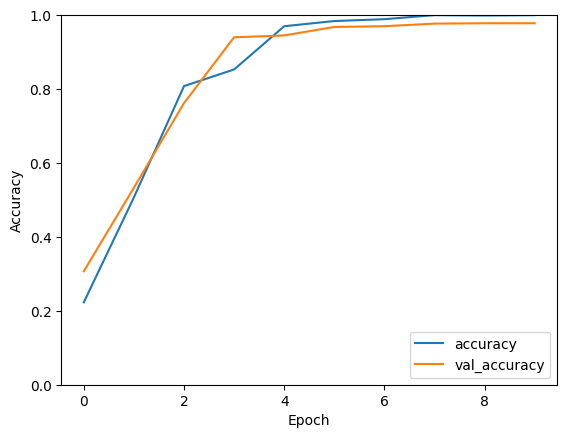

In [31]:
plt.plot(result_V.history['accuracy'], label='accuracy')
plt.plot(result_V.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')